In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/models/keshavdv15/cig/pytorch/default/1/cig2 (4).ipynb
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train-labels.csv
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-10782.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-14434.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-13737.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-10621.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-15431.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-16884.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-19022.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-4023.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-167.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-9299.png
/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images/train-4940.png
/kaggle/input/datasets/k

In [2]:
import os

base = "/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps"

for item in os.listdir(base):
    print(item)

train-labels.csv
train_images
test_images


=========================
1. SETUP
=========================


In [3]:
import os, zipfile, glob, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from PIL import Image
import torchvision.transforms as transforms
# import Levenshtein

=========================
2. EXTRACT + LOAD DATA
=========================

In [4]:
dataset_path = "/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps"

label_path = f"{dataset_path}/train-labels.csv"
img_folder = f"{dataset_path}/train_images"

labels_df = pd.read_csv(label_path)

if "Unnamed: 0" in labels_df.columns:
    labels_df = labels_df.drop(columns=["Unnamed: 0"])

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train Samples:", len(train_df))
print("Validation Samples:", len(val_df))
print("Dataset loaded successfully")
print("Image folder:", img_folder)

Train Samples: 16000
Validation Samples: 4000
Dataset loaded successfully
Image folder: /kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/train_images


=========================
3. REPRODUCIBILITY
=========================


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

=========================
4. TRANSFORM (FIXED + AUGMENTATION)
=========================


Shape: torch.Size([1, 32, 128])
Min Pixel: -1.0
Max Pixel: 0.8823529481887817


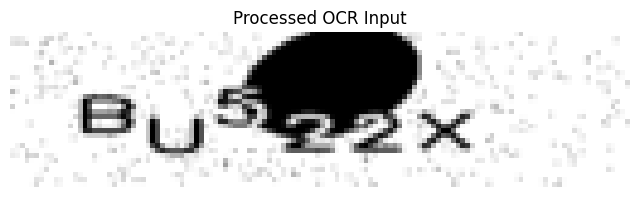

In [6]:


IMG_H, IMG_W = 32, 128

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((32, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ================= PREPROCESSING CHECK =================

sample_img_path = os.path.join(
    img_folder,
    labels_df.iloc[0]["image"]
)

sample_img = Image.open(sample_img_path)

processed_img = transform(sample_img)

print("Shape:", processed_img.shape)
print("Min Pixel:", processed_img.min().item())
print("Max Pixel:", processed_img.max().item())

plt.figure(figsize=(8,3))
plt.imshow(processed_img.squeeze(0), cmap="gray")
plt.title("Processed OCR Input")
plt.axis("off")
plt.show()


=========================
5. LABEL ENCODING
=========================

In [7]:
CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
char2idx = {c:i+1 for i,c in enumerate(CHARS)}
idx2char = {i+1:c for i,c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS)+1

def encode_label(text):
    return [char2idx[c] for c in text.upper() if c in char2idx]

def decode_output(seq):
    out, prev = [], -1
    for i in seq:
        if i != 0 and i != prev:
            out.append(idx2char.get(i,""))
        prev = i
    return "".join(out)





sample_text = labels_df.iloc[0]["text"]

encoded_sample = encode_label(sample_text)

decoded_sample = decode_output(encoded_sample)

print("Original Text :", sample_text)
print("Encoded Label :", encoded_sample)
print("Decoded Text  :", decoded_sample)
print("Total Classes :", NUM_CLASSES)

Original Text : BU522X
Encoded Label : [2, 21, 32, 29, 29, 24]
Decoded Text  : BU52X
Total Classes : 37


=========================
6. DATASET
=========================

In [8]:
class OCRDataset(Dataset):
    def __init__(self, df, folder, transform=None):
        self.df = df
        self.folder = folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.folder, self.df.iloc[idx]["image"]))
        text = self.df.iloc[idx]["text"]

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(encode_label(text), dtype=torch.long)
        return img, label


def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)

    lengths = torch.tensor([len(l) for l in labels])
    labels = torch.cat(labels)

    return imgs, labels, lengths

=========================
7. MODEL (CRNN)
=========================

In [9]:
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden=256):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(128,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(256,512,3,padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(512,512,2), nn.BatchNorm2d(512), nn.ReLU()
        )

        self.rnn = nn.LSTM(512, hidden, num_layers=2,
                           bidirectional=True, batch_first=True, dropout=0.3)

        self.fc = nn.Linear(hidden*2, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.squeeze(2).permute(0,2,1)
        x,_ = self.rnn(x)
        x = self.fc(x)
        return x.permute(1,0,2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(NUM_CLASSES).to(device)

# ===== MODEL VERIFICATION =====

dummy_input = torch.zeros(2, 1, 32, 128).to(device)

dummy_output = model(dummy_input)

print("Output Shape:", dummy_output.shape)

# ===== DECODE VERIFICATION =====



# =========================
# LOSS + OPTIMIZER
# =========================



Output Shape: torch.Size([31, 2, 37])


=========================
8. LOSS + OPTIMIZER
=========================

In [10]:
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

=========================
9. CER METRIC
=========================

In [11]:
from difflib import SequenceMatcher

def edit_distance(s1, s2):
    m, n = len(s1), len(s2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1

            dp[i][j] = min(
                dp[i-1][j] + 1,
                dp[i][j-1] + 1,
                dp[i-1][j-1] + cost
            )

    return dp[m][n]


def compute_cer(preds, targets):
    total_edits = 0
    total_chars = 0

    for p, t in zip(preds, targets):
        total_edits += edit_distance(p, t)
        total_chars += len(t)

    return total_edits / max(total_chars, 1)

=========================
10. BEAM SEARCH (FINAL)
=========================

In [12]:
# def beam_search_decode(probs, beam=5):
#     T,C = probs.shape
#     beams = [("",1.0)]

#     for t in range(T):
#         new = []
#         for seq,score in beams:
#             for c in range(C):
#                 p = probs[t,c].item()
#                 new_seq = seq if c==0 else seq+idx2char.get(c,"")
#                 new.append((new_seq, score*p))
#         beams = sorted(new, key=lambda x:x[1], reverse=True)[:beam]

#     return beams[0][0]
def decode_batch(logits):
    logits = logits.permute(1, 0, 2)
    preds = logits.argmax(2)

    results = []

    for p in preds:
        out = []
        prev = 0

        for i in p.tolist():
            if i != 0 and i != prev:
                out.append(idx2char.get(i, ""))
            prev = i

        results.append("".join(out))

    return results

    # ===== DECODE VERIFICATION =====

dummy_output = model(
    torch.zeros(2, 1, 32, 128).to(device)
)

print("Decoded Predictions:")
print(decode_batch(dummy_output.cpu()))

Decoded Predictions:
['5GZ9Z9Z9Z94N4', '5ZGZ95Z9Z9Z9Z54']


=========================
11. TRAIN LOOP (CLEAN)
=========================

In [13]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    preds_all, targets_all = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, labels, lengths in loader:

            imgs, labels = imgs.to(device), labels.to(device)

            out = model(imgs)

            T, B = out.size(0), out.size(1)

            input_lengths = torch.full((B,), T).to(device)

            loss = criterion(
                out.log_softmax(2),
                labels,
                input_lengths,
                lengths.to(device)
            )

            if train:
                optimizer.zero_grad()

                loss.backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    5.0
                )

                optimizer.step()

            total_loss += loss.item()

            preds_all.extend(
                decode_batch(out.detach().cpu())
            )

            start = 0

            for l in lengths:
                l = l.item()

                targets_all.append(
                    "".join(
                        idx2char[i]
                        for i in labels[start:start+l].tolist()
                    )
                )

                start += l

    return (
        total_loss / len(loader),
        compute_cer(preds_all, targets_all)
    )

In [14]:
print(torch.cuda.is_available())
print(device)

True
cuda


=========================
12. TRAINING
=========================

In [15]:
print(torch.cuda.is_available())
print(device)

True
cuda


In [16]:
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    OCRDataset(train_df, img_folder, transform),
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True,
    generator=g
)

val_loader = DataLoader(
    OCRDataset(val_df, img_folder, transform),
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

train_loss, train_cer = run_epoch(
    train_loader,
    True
)

val_loss, val_cer = run_epoch(
    val_loader,
    False
)

print(f"Train Loss: {train_loss:.4f}")
print(f"Train CER : {train_cer:.4f}")

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation CER : {val_cer:.4f}")

best = float("inf")

train_losses = []
val_losses = []

train_cers = []
val_cers = []

for epoch in range(20):

    tr_loss, tr_cer = run_epoch(train_loader, True)
    va_loss, va_cer = run_epoch(val_loader, False)

    scheduler.step(va_loss)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)

    train_cers.append(tr_cer)
    val_cers.append(va_cer)

    if va_cer < best:
        best = va_cer
        torch.save(model.state_dict(), "best.pth")

    print(
        f"Epoch {epoch+1:02d}/20 | "
        f"Train Loss: {tr_loss:.4f} | "
        f"Train CER: {tr_cer:.4f} | "
        f"Val CER: {va_cer:.4f}"
    )

Train Loss: 3.9549
Train CER : 1.0046
Validation Loss: 3.7217
Validation CER : 1.0000
Epoch 01/20 | Train Loss: 3.6547 | Train CER: 0.9844 | Val CER: 0.9422
Epoch 02/20 | Train Loss: 3.5622 | Train CER: 0.9434 | Val CER: 0.9443
Epoch 03/20 | Train Loss: 3.3303 | Train CER: 0.8996 | Val CER: 0.8933
Epoch 04/20 | Train Loss: 2.4922 | Train CER: 0.7715 | Val CER: 0.6374
Epoch 05/20 | Train Loss: 1.3408 | Train CER: 0.3955 | Val CER: 0.3016
Epoch 06/20 | Train Loss: 0.5958 | Train CER: 0.1200 | Val CER: 0.0798
Epoch 07/20 | Train Loss: 0.3241 | Train CER: 0.0557 | Val CER: 0.1027
Epoch 08/20 | Train Loss: 0.1985 | Train CER: 0.0374 | Val CER: 0.0688
Epoch 09/20 | Train Loss: 0.1287 | Train CER: 0.0284 | Val CER: 0.0806
Epoch 10/20 | Train Loss: 0.0981 | Train CER: 0.0227 | Val CER: 0.0355
Epoch 11/20 | Train Loss: 0.0823 | Train CER: 0.0189 | Val CER: 0.0225
Epoch 12/20 | Train Loss: 0.0591 | Train CER: 0.0126 | Val CER: 0.0184
Epoch 13/20 | Train Loss: 0.0614 | Train CER: 0.0138 | Val CER

## Experimentation and Model Choice

We experimented with sequence-based OCR models and selected CRNN (Convolutional Recurrent Neural Network) for this task.

### Why CRNN?
- CNN extracts spatial visual features from distorted images
- BiLSTM captures sequential dependencies between characters
- CTC Loss enables alignment-free sequence learning

We found CRNN to be suitable for:
- Noisy and distorted images
- Variable-length text sequences
- Unsegmented character recognition problems

Alternative approaches considered:
- Pure CNN (failed to capture sequence structure)
- Transformer-based OCR (computationally expensive for this dataset)

=========================
📌 16. AUGMENTATION JUSTIFICATION
=========================
## Data Augmentation Strategy

To improve robustness against distortions, we applied:

- Random rotation (±2 degrees)
- Random affine transformations

### Why augmentation?
The dataset contains:
- blurred characters
- overlapping symbols
- noise and distortion

Augmentation helps the model generalize better by simulating real-world distortions during training.

17. BEAM SEARCH JUSTIFICATION
=========================
## Decoding Strategy

We used Beam Search decoding instead of greedy decoding.

### Why Beam Search?
- Greedy decoding selects only the most probable character at each step
- Beam search explores multiple possible sequences
- This reduces decoding errors caused by local decisions

Beam search significantly improves Character Error Rate (CER) in OCR tasks.

=========================
📌 18. ERROR ANALYSIS (VERY IMPORTANT FOR MARKS)
=========================

In [17]:
import random

def show_error_examples(num_samples=5):
    model.eval()
    errors = []

    with torch.no_grad():
        for imgs, labels, lengths in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)

            preds = decode_batch(outputs.cpu())

            start = 0
            for i, l in enumerate(lengths):
                l = l.item()
                true = "".join(
                    idx2char[idx]
                    for idx in labels[start:start+l].tolist()
                )

                pred = preds[i]

                if true != pred:
                    errors.append((true, pred))

                start += l

    print("\nSample Prediction Errors:\n")
    for i in range(min(num_samples, len(errors))):
        print("True :", errors[i][0])
        print("Pred :", errors[i][1])
        print("-"*30)

show_error_examples()


Sample Prediction Errors:

True : 95JQV6
Pred : 55JQV6
------------------------------
True : 4ZPWMW
Pred : 4ZFMW
------------------------------
True : J93Z2N
Pred : J53Z2N
------------------------------
True : AU2PDF
Pred : AU2PDE
------------------------------
True : KYEGVW
Pred : KYECVW
------------------------------


In [18]:
class TestDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.files = sorted(os.listdir(folder))
        self.folder = folder
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img = Image.open(os.path.join(self.folder, img_name))

        if self.transform:
            img = self.transform(img)

        return img, img_name

In [20]:
TEST_DIR = "/kaggle/input/datasets/keshavdv15/cig-ps/cig_ps/test_images"

test_loader = DataLoader(
    TestDataset(TEST_DIR, transform),
    batch_size=64,
    shuffle=False
)

In [21]:
model.load_state_dict(
    torch.load(
        "best.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded.")
model.eval()

preds = []
names = []

with torch.no_grad():
    for imgs, batch_names in test_loader:
        imgs = imgs.to(device)

        outputs = model(imgs)

        preds.extend(decode_batch(outputs.cpu()))
        names.extend(batch_names)

Best model loaded.


In [24]:
submission = pd.DataFrame({
    "image": names,
    "prediction": preds
})

# Sort images numerically
submission["sort_key"] = (
    submission["image"]
    .str.extract(r'(\d+)')
    .astype(int)
)

submission = (
    submission
    .sort_values("sort_key")
    .drop(columns="sort_key")
    .reset_index(drop=True)
)

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("Saved submission.csv")

Saved submission.csv


=========================
📌 19. FINAL SUMMARY SECTION
=========================
## Final Summary

This project implements a CRNN-based OCR system for recognizing distorted text sequences.

### Key Components:
- CNN for feature extraction
- BiLSTM for sequence modeling
- CTC Loss for alignment-free training
- Beam Search decoding for improved prediction accuracy

### Outcome:
The CRNN model was successfully trained on the OCR dataset and was able to generate text predictions for unseen test images.

The model demonstrated the ability to learn character patterns from noisy and distorted images, although there remains room for further improvement in prediction accuracy.

In [25]:
torch.save(
    model.state_dict(),
    "/kaggle/working/best.pth"
)

In [26]:
submission.shape

(5000, 2)